

# Knit App: The Making of

**By Kaste Ivanauskaite**

Knitting is essentially building body-shaped structures, which means it relies heavily on math and involves a lot of planning. Designing a custom colorwork sweater from scratch is tedious because you are trying to map flat, digital pixel art onto a physical 3D object that has its own gauge, ease, and topography.

I built Knit App to automate the array math and shaping calculations, allowing the user to focus on building their own colourwork design. Here is a breakdown of the core problems I needed to solve and how the architecture handles them.

### 1. Digitizing the Art

The first issue was figuring out how to turn a standard image (like a PNG or a JPEG) into a knittable pattern. The usual way most knitters go about putting a pixel design onto a sweater involves finding an alpha pattern image on sites like Pinterest, downloading it and calculating the placement of the pattern on the sweater. I wanted that workflow to be compatible with my app, so I needed to develop an engine that can read pixel images and convert them into a matrix of 1s and 0s for the computer to read.

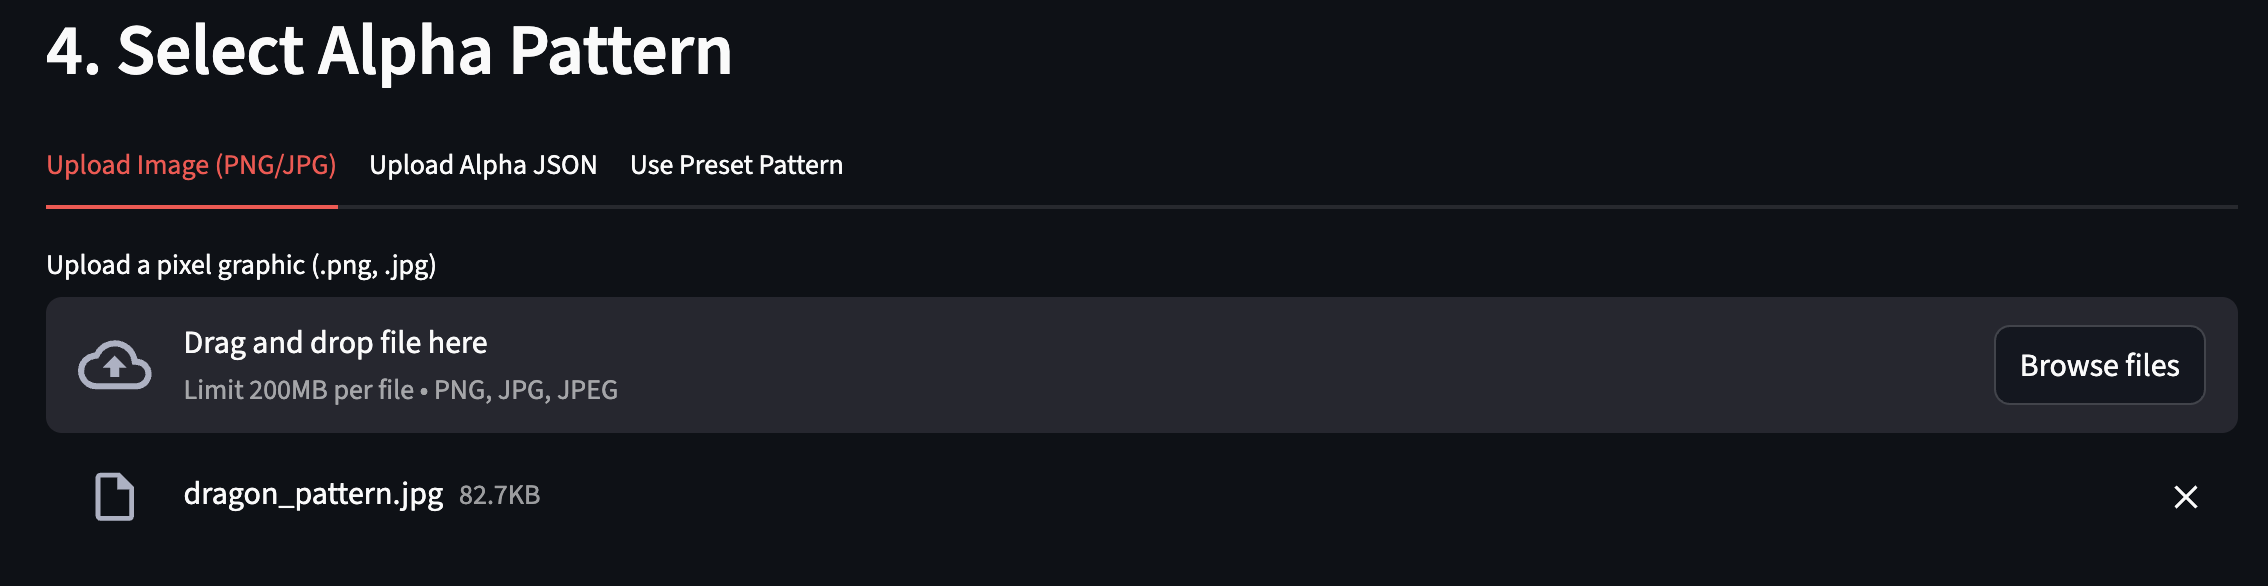

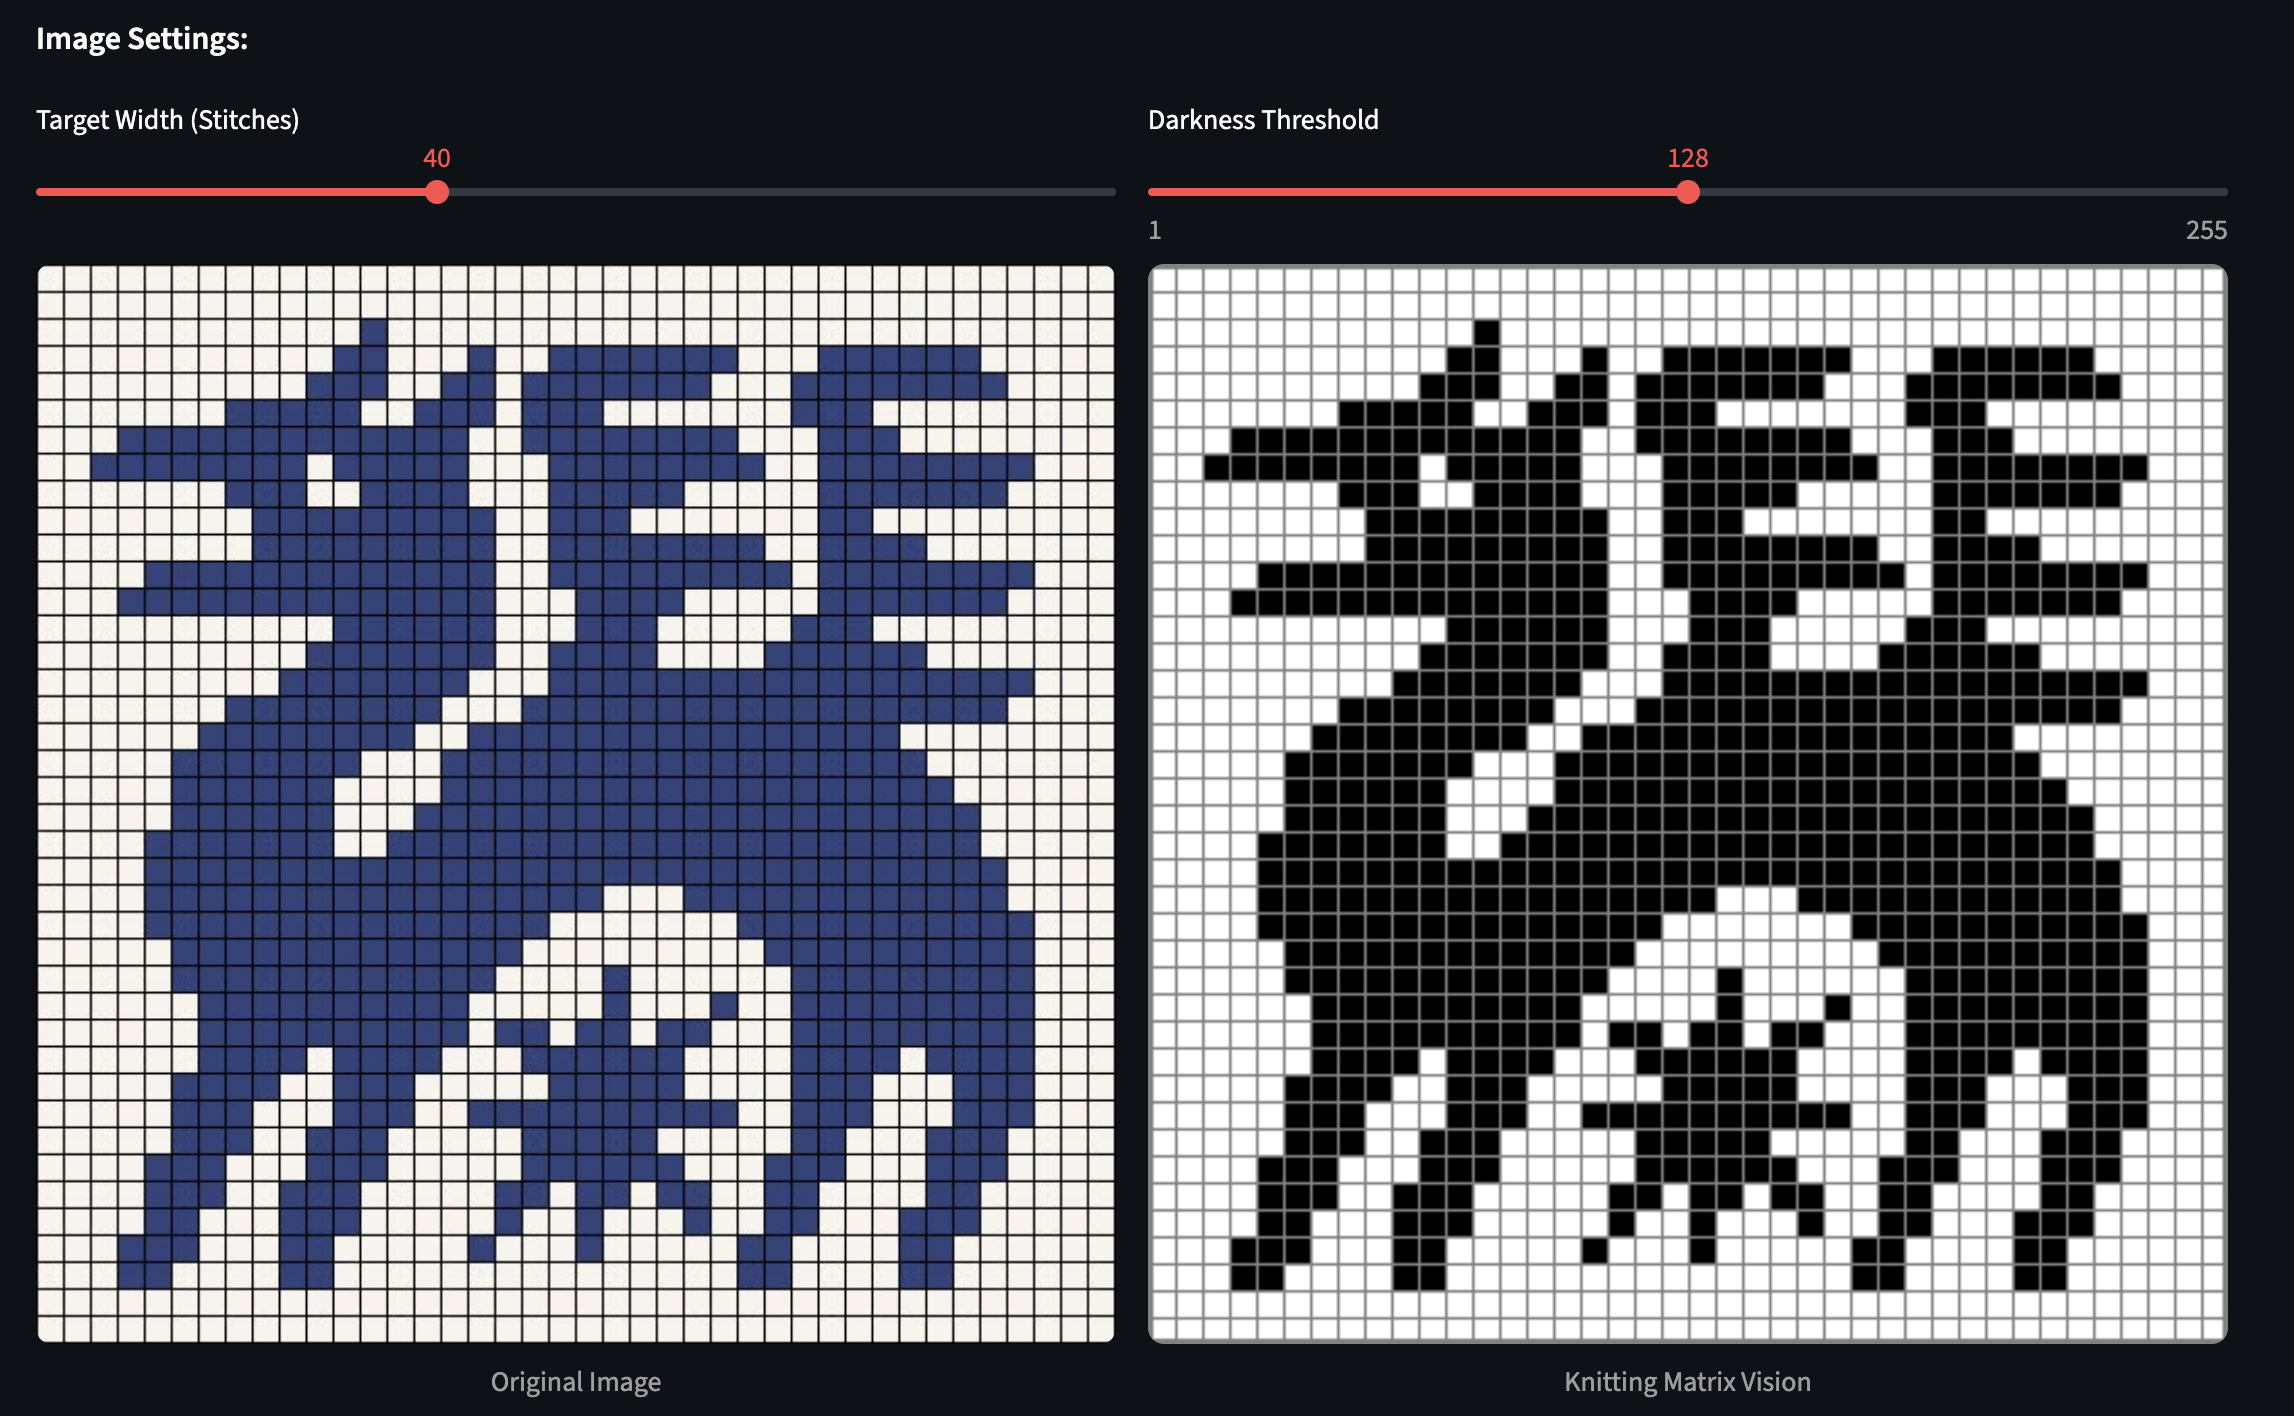

**The Implementation:** The image engine processes the upload by first calculating the physical aspect ratio based on the user's input gauge. For the resampling, I used a Box algorithm rather than standard Lanczos or Bicubic filters. Standard filters create anti-aliasing (blurry edges), which is useless for knitting. Box resampling forces hard, binary edges. From there, I implemented a thresholding slider that converts the grayscale NumPy array into a pure binary matrix of `1`s (stitches) and `0`s (background space). An unintended effect of these width and darkness threshold sliders was being able to pixelate regular images.

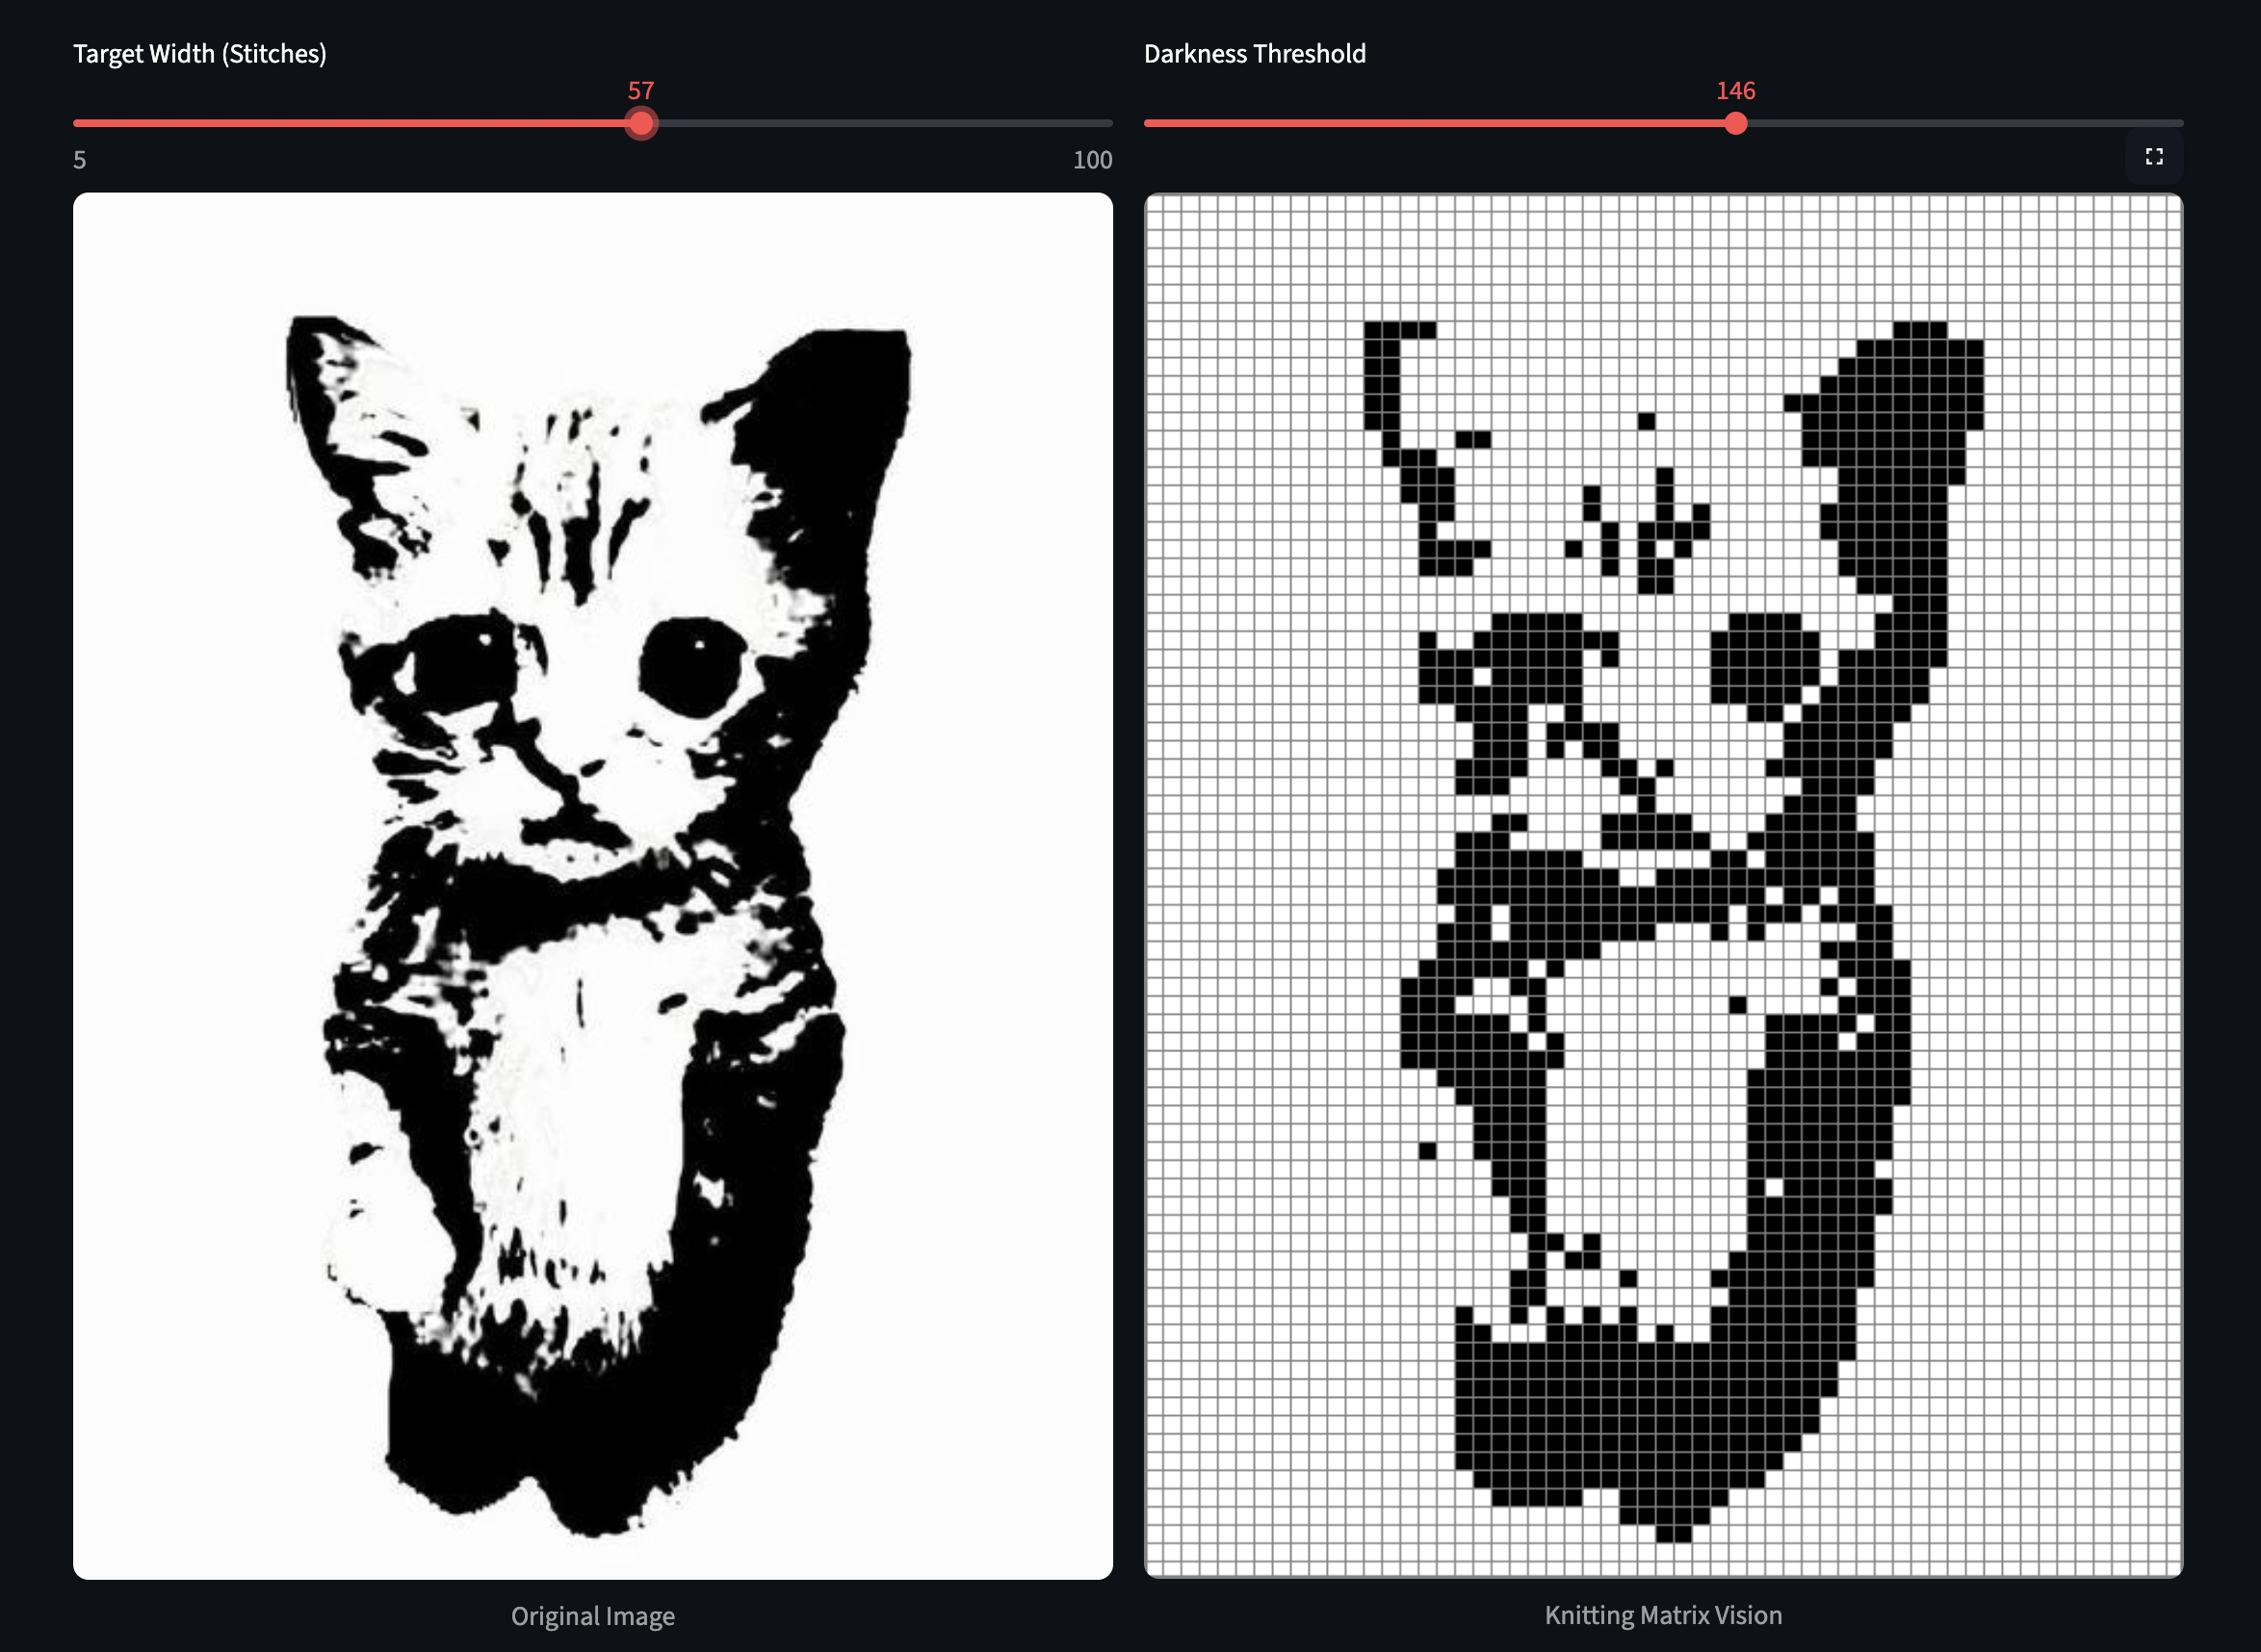

**Perfection issues:** The pixel width and darkness thrshold manipulation was decent at converting the image to a pixelated array, however, it wasn't *perfect*, which I could not deal with. This led to the implementation of a very rudimentary pixel editing feature that is basically an excel sheet of checked and unchecked boxes. It is not meant to be used as a design software, even though you have the option to do that with preset empty 25x25 and 50x50 canvases. I have edited some designs pretty heavily and, while it's a bit tedious, it works pretty well.

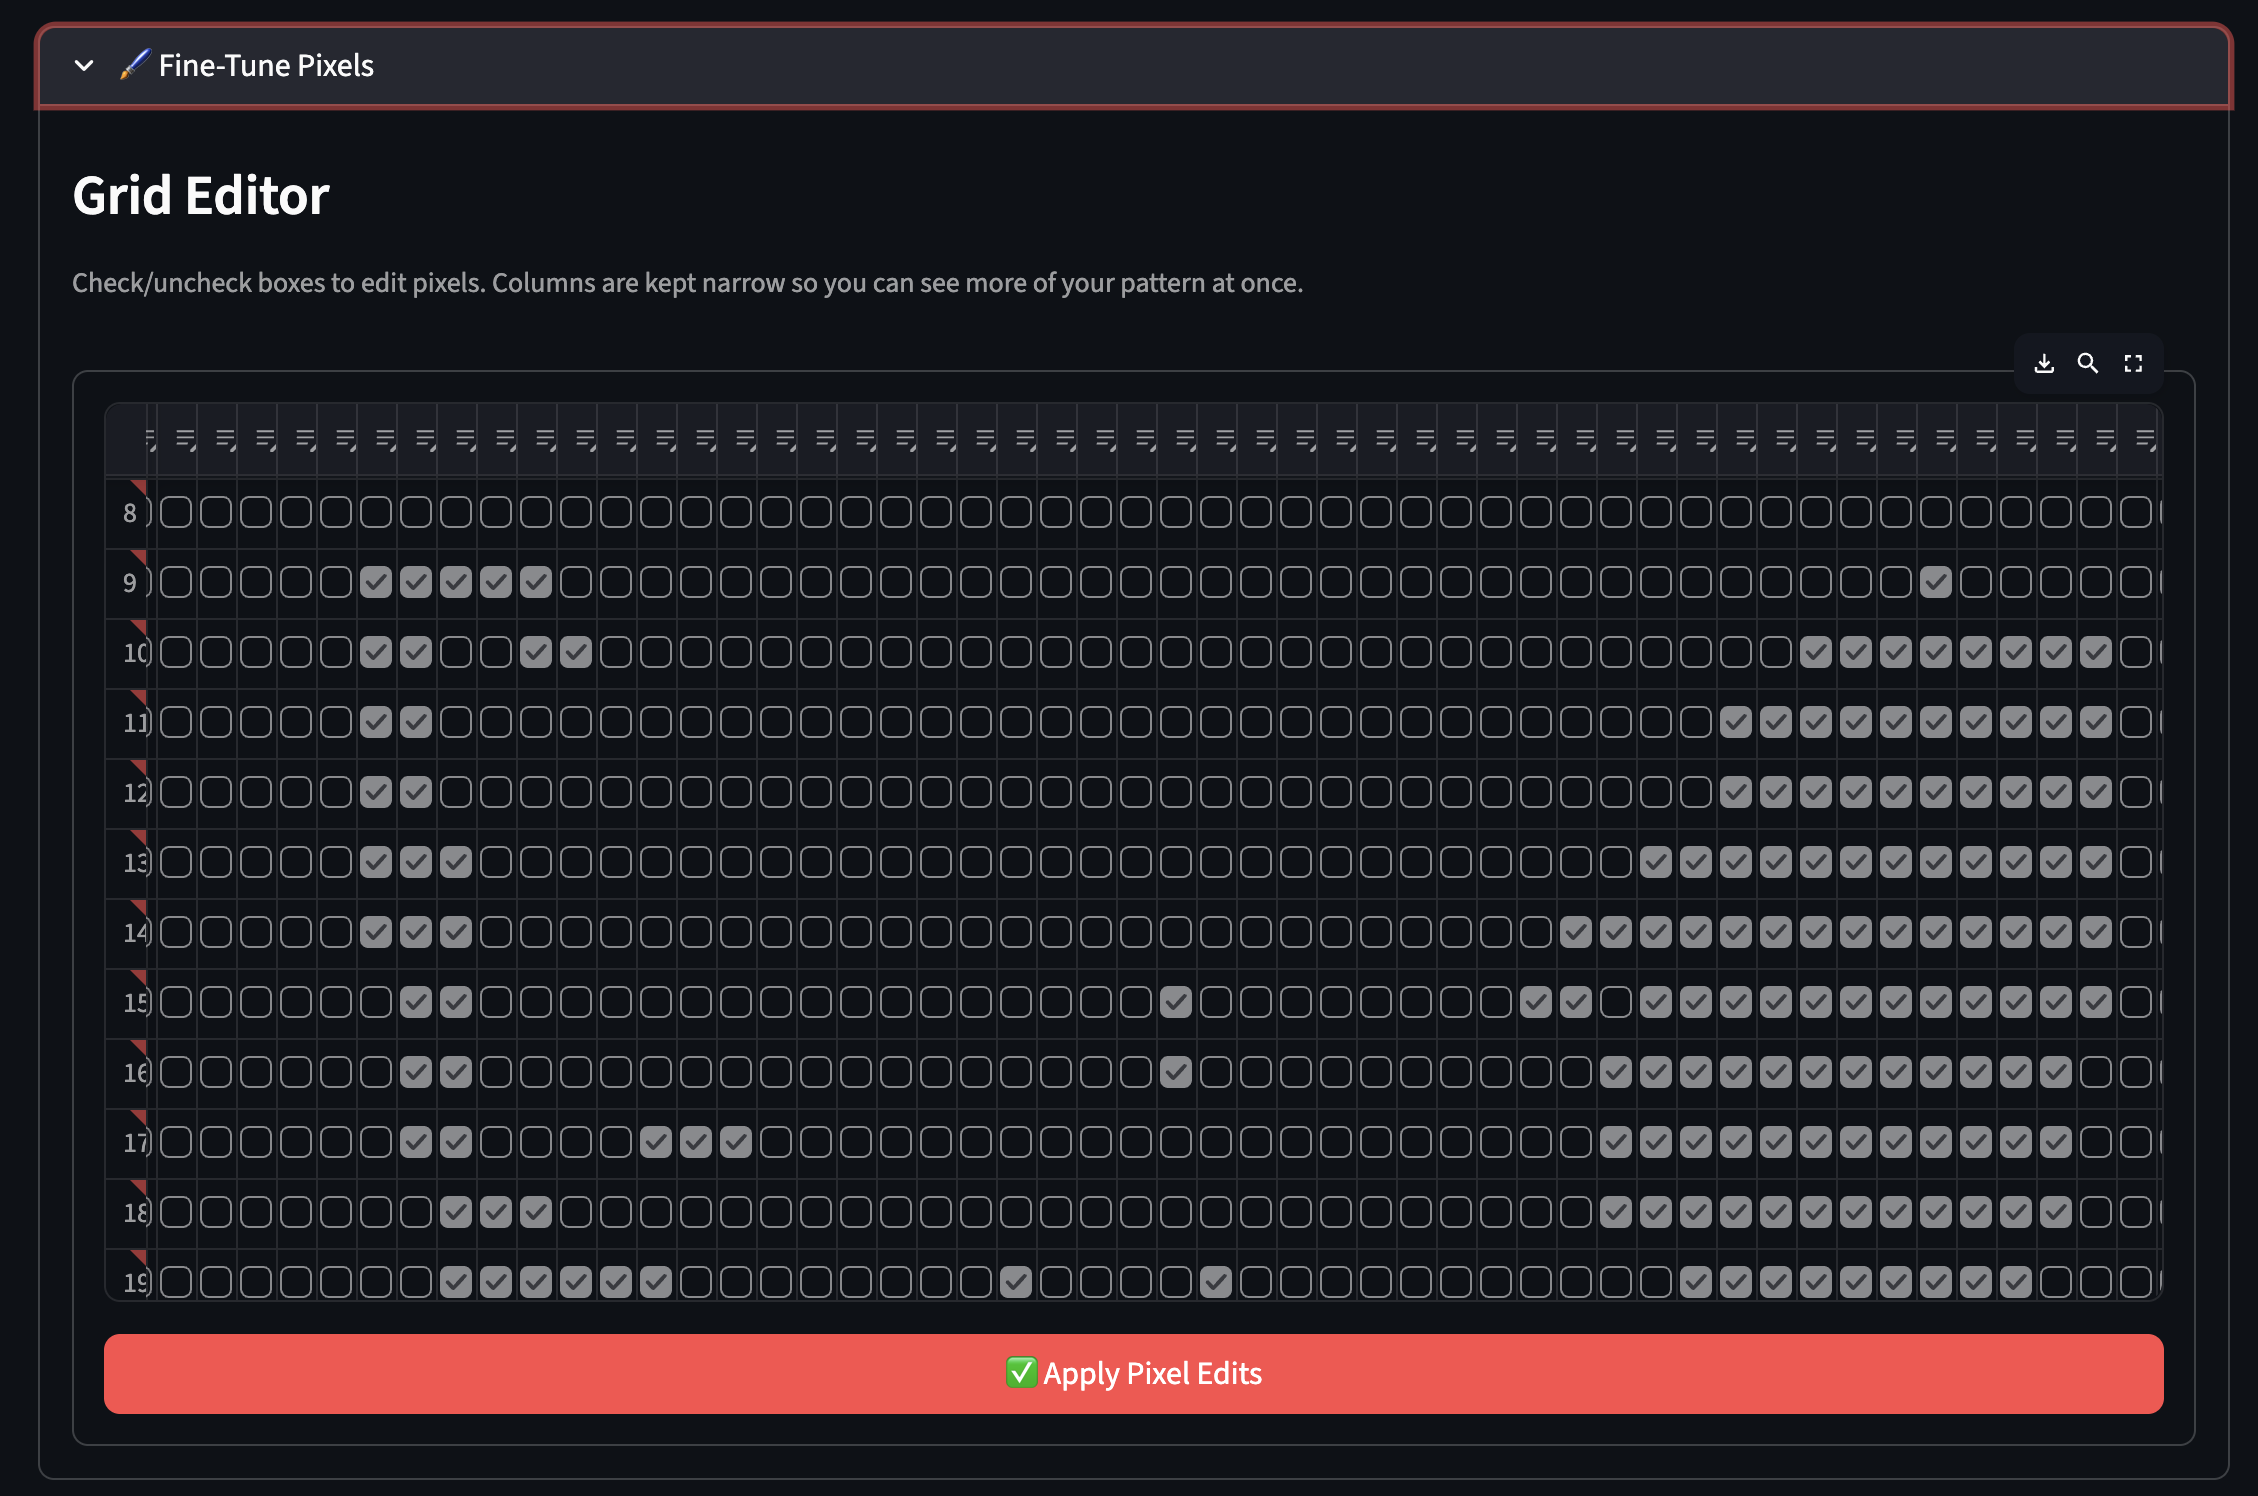

### 2. Building the Topography (The Math Engine)

The gauge and size math was not hard to code in based on sizing. Alongside standard sizing, I added a few advanced sizing settings, based on chest circumference, intended positive ease (it can go negative too, if you are doing ribbing or something stretchy), and intended lentgh.


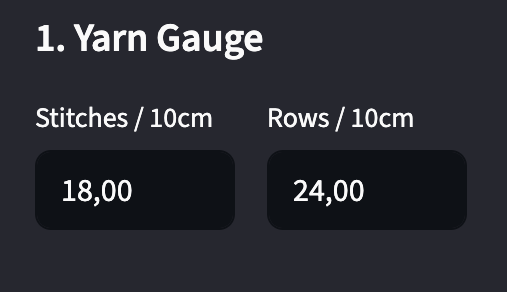

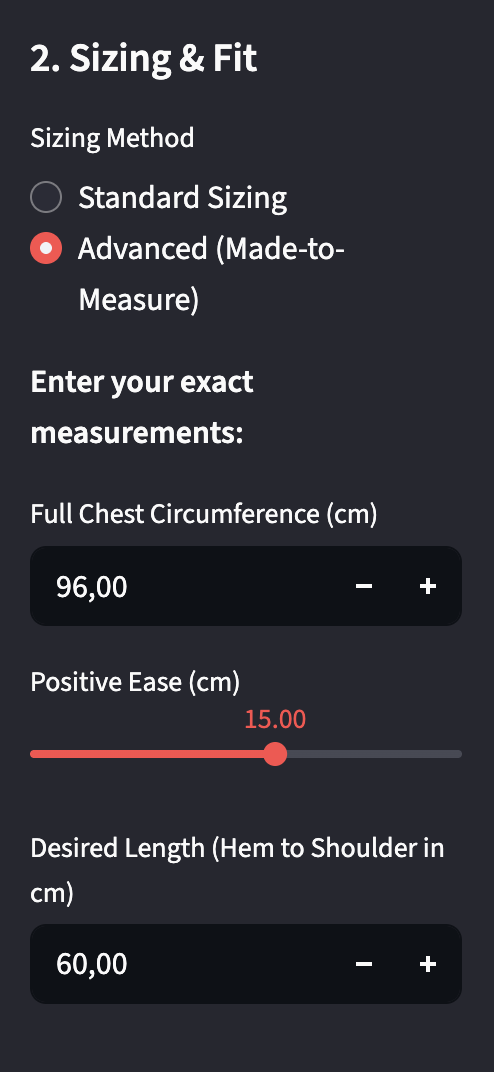

For a good fit you can’t just paste a graphic onto a flat rectangle; sweaters have sloped shoulders and raised backs shaped by short rows. I needed a way to represent "empty space" in a mathematical grid.

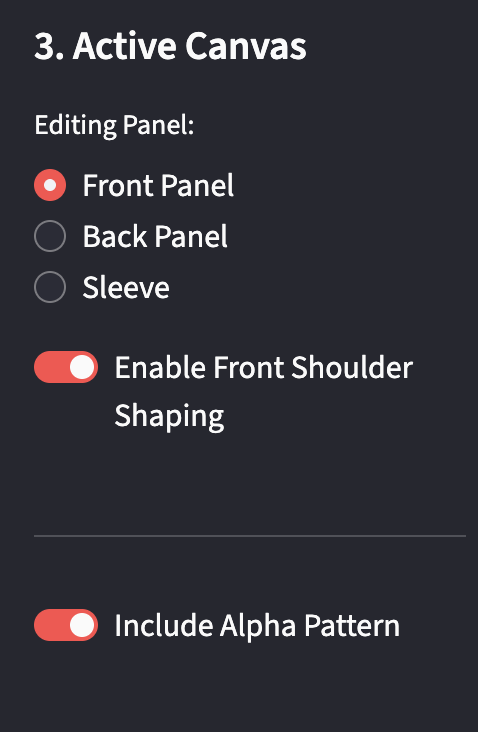

**The Implementation:** When the user inputs their target size and gauge, the math engine generates a base 2D matrix filled with `0`s (representing an knittable canvas).

To calculate the neck and shoulder shaping, I wrote a topographical algorithm based on standard human body measurements. It calculates the necessary German Short Row steps and iterates through the top rows of the matrix, replacing specific `0`s with `-1`s. The `-1` acts as a mask for "dead space." To make the final knitting chart actually readable, the algorithm intentionally delays the left shoulder shaping by exactly one row to create an asymmetrical curve seen in german short row shaping.

### 3. Layering

Once the base sweater matrix is carved out, the user needs to be able to place, rotate, and scale their digitized alpha patterns onto the canvas. A popular pattern making technique when making colourwork is duplicating and mirroring alphas to create a seamless repeating pattern, so I wanted to implement this as well.

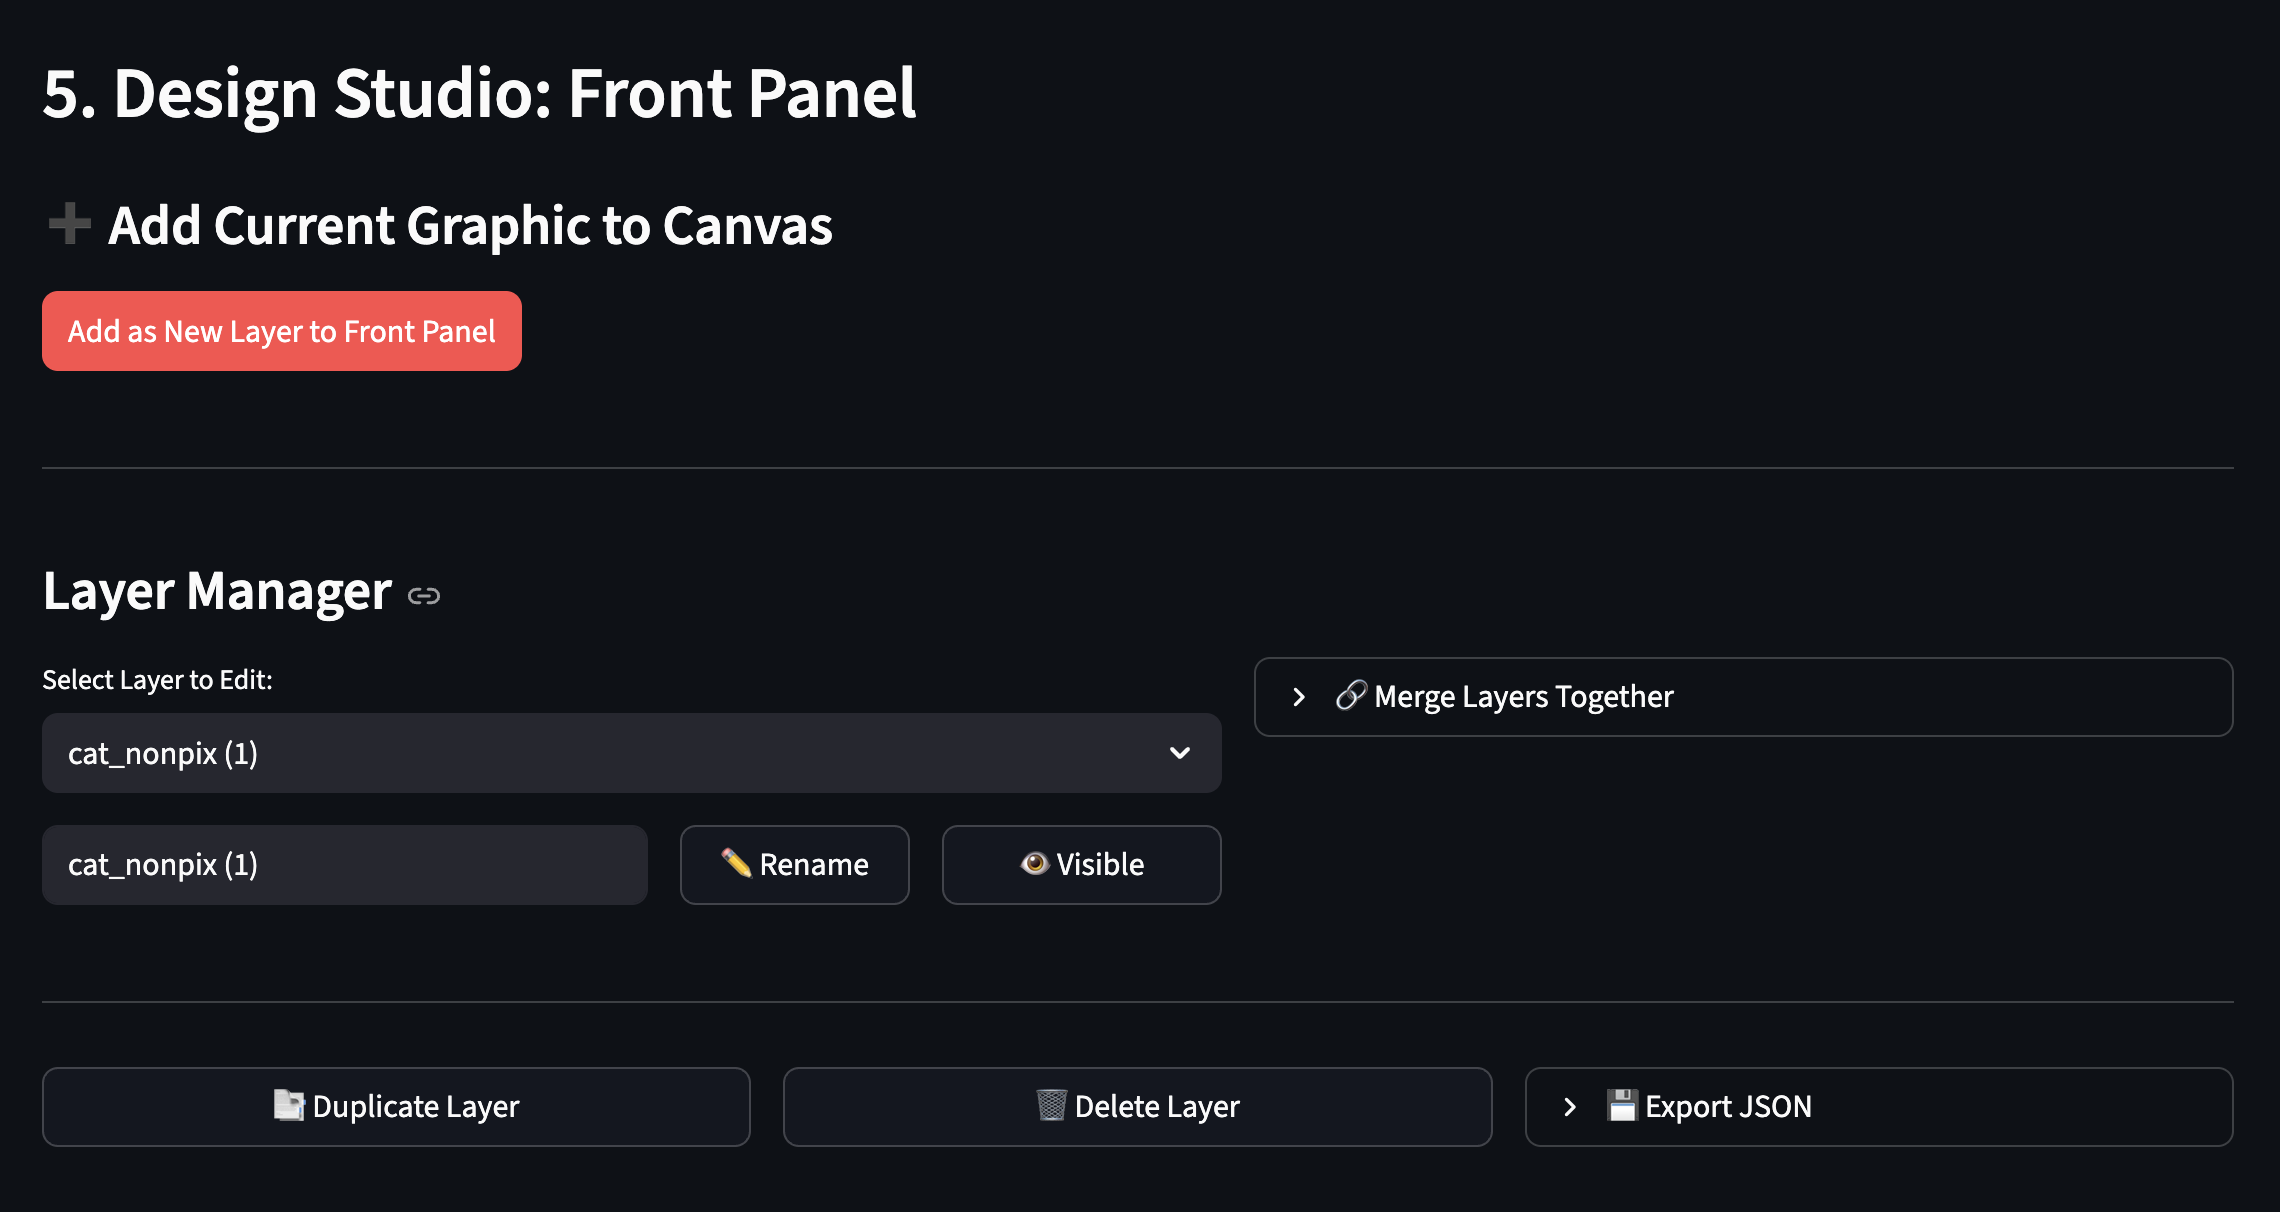

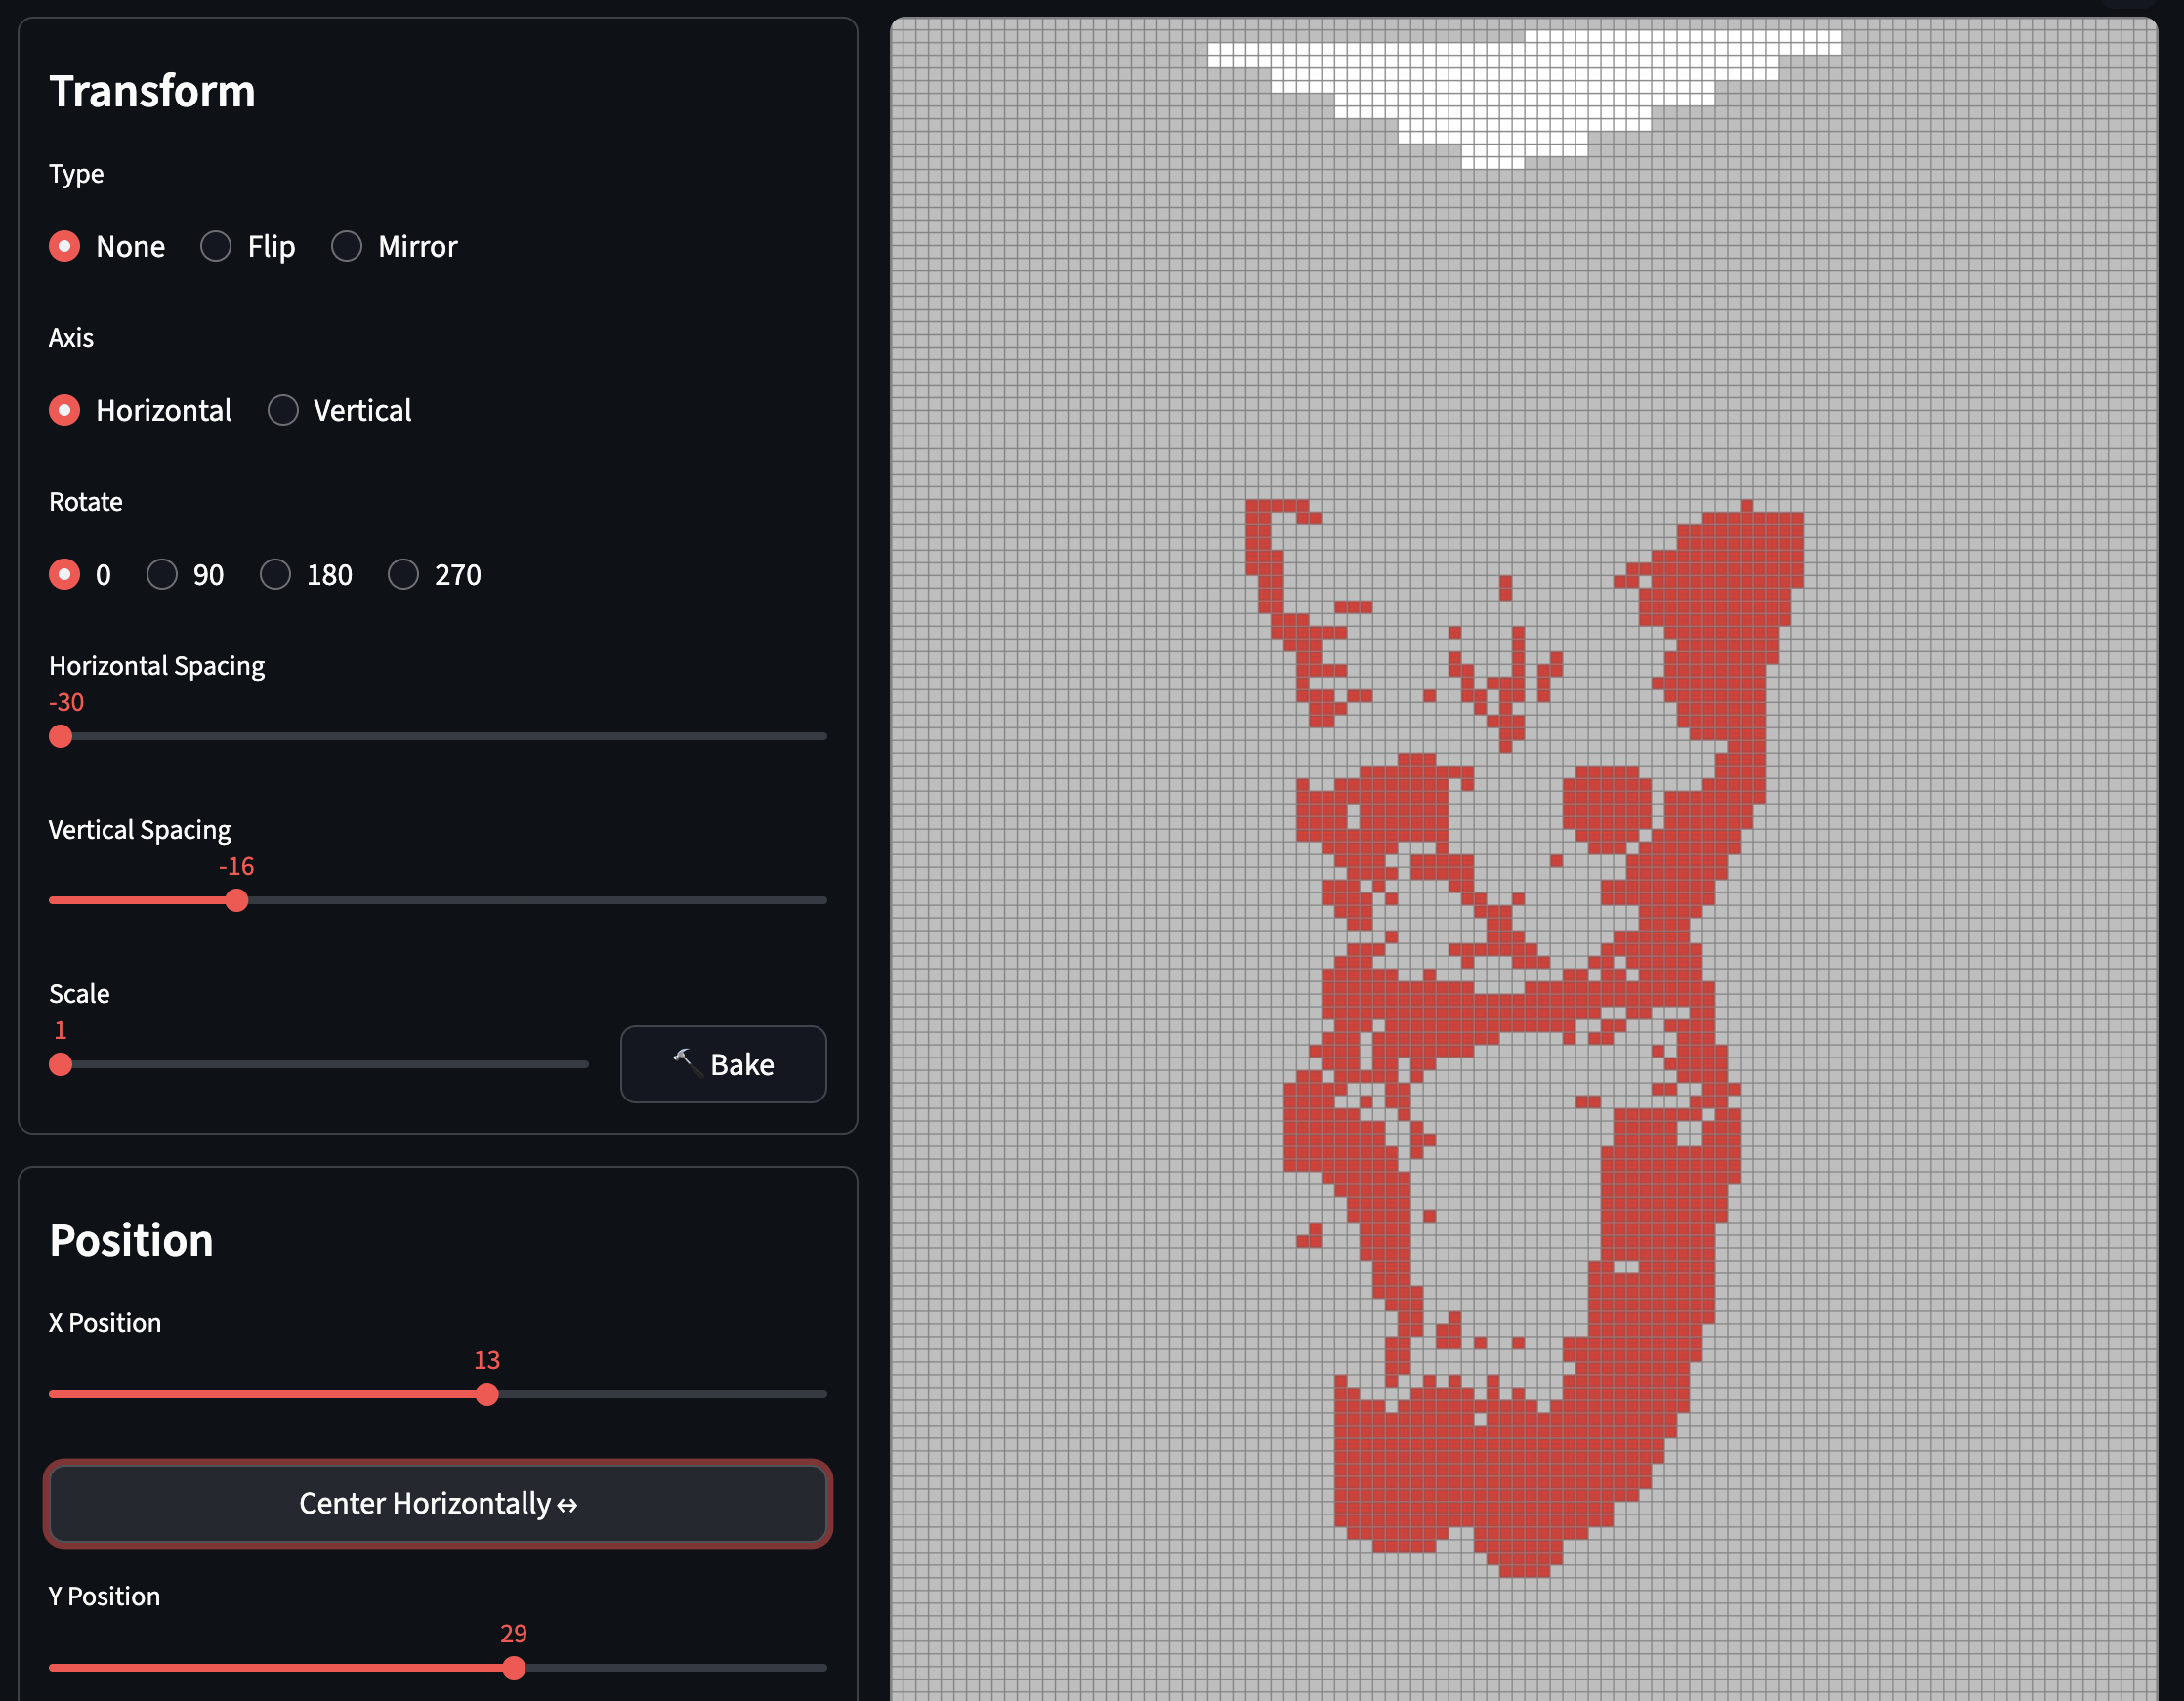

**The Implementation:**
I built a Layer Design Studio to handle multiple graphic objects. I ran into some problems trying to implement scaling in combination with the fine-tune pixel editor, so I implemented a button to 'Bake' the scale up into the image. This make it possible to edit the smaller individual pixels after scaling up. Centering horizontally and vertically after using mirroring tools and merging layers struggled because of the new center of the alpha graphic. This led me to implement alpha 'wrapping' that detects the border of the new alpha pattern before centeringand moving the image. This also led to the implementation of the exporting JSON alpha, to be able to reuse the pixelated image. 

### 4. Compiling the Final PDF

A digital canvas is helpful for designing, but nobody wants to knit while staring at a 200x300 matrix on a laptop screen. The final requirement was exporting the data into a standard, readable knitting pattern. I included instructions, the specs of the garment, and the full knitting chart, with customizable size per page for better readability.


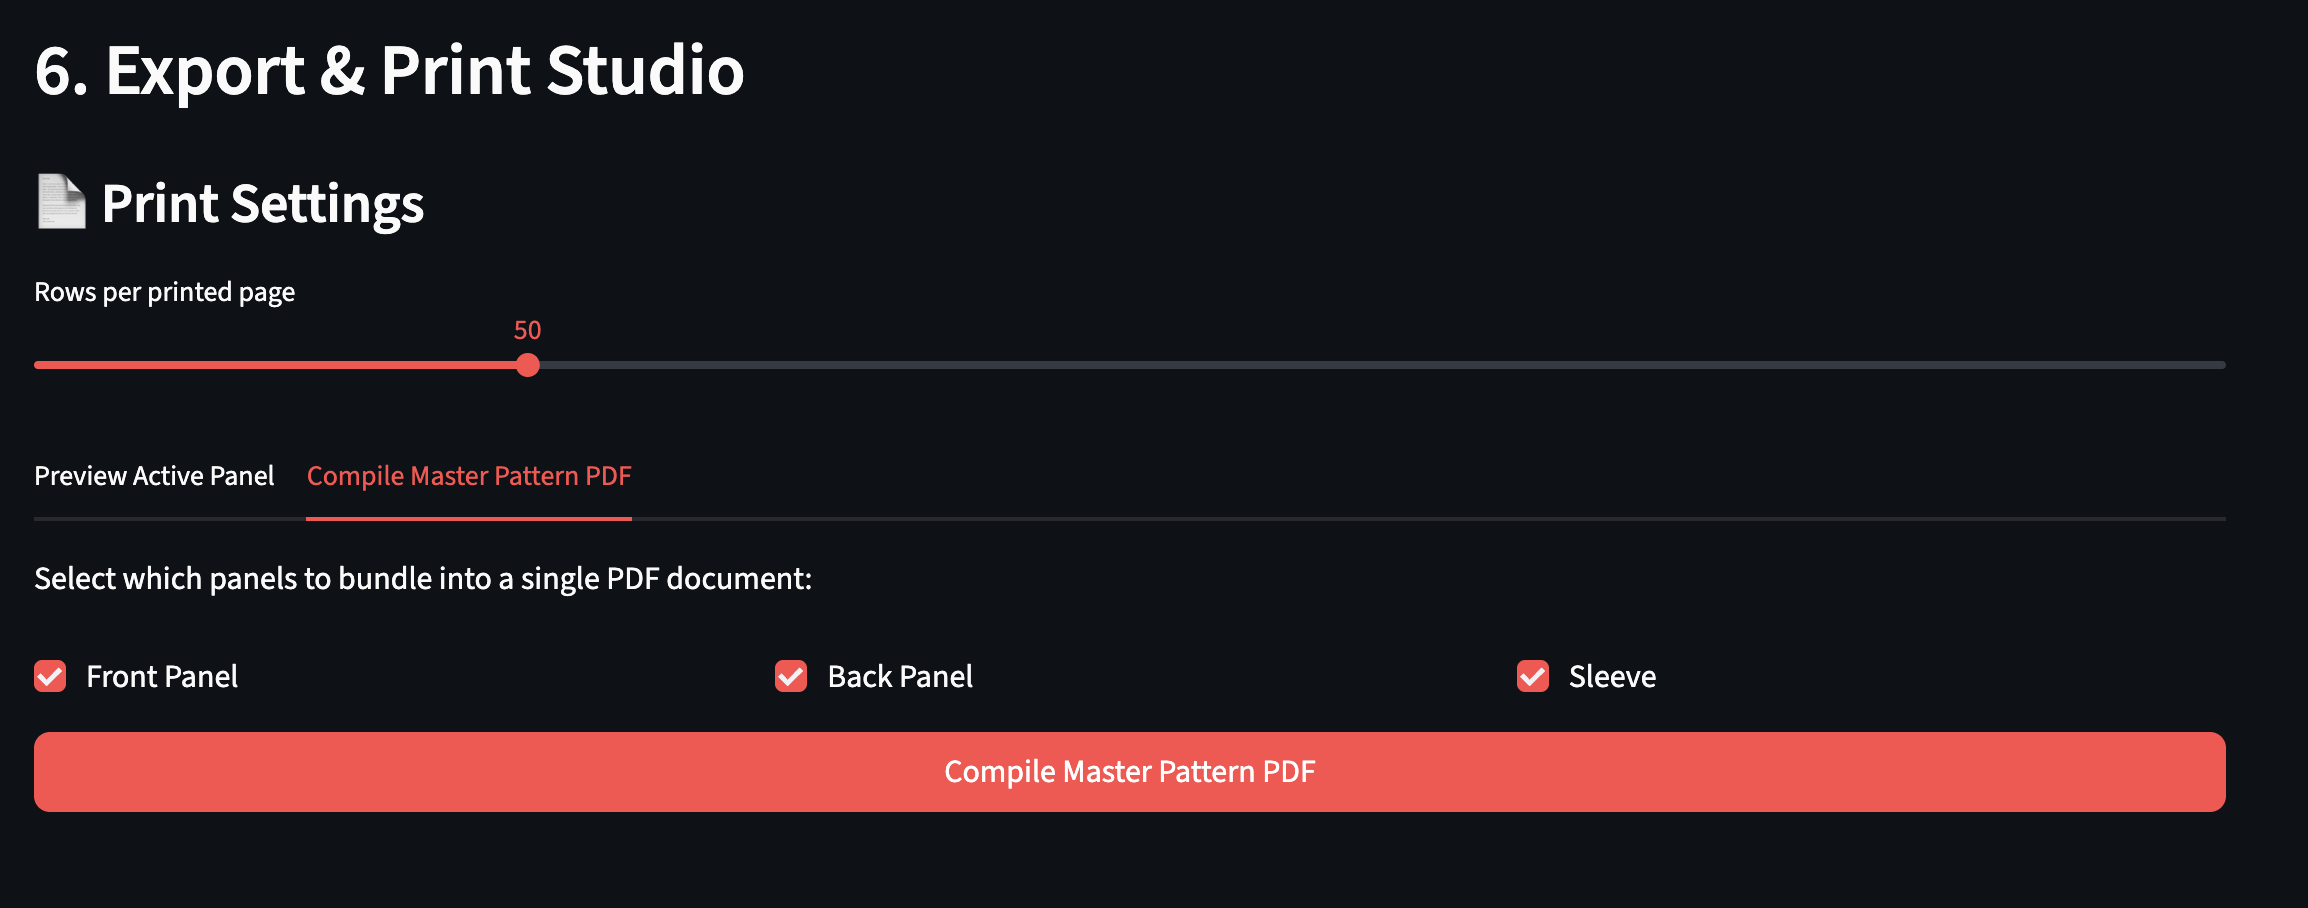

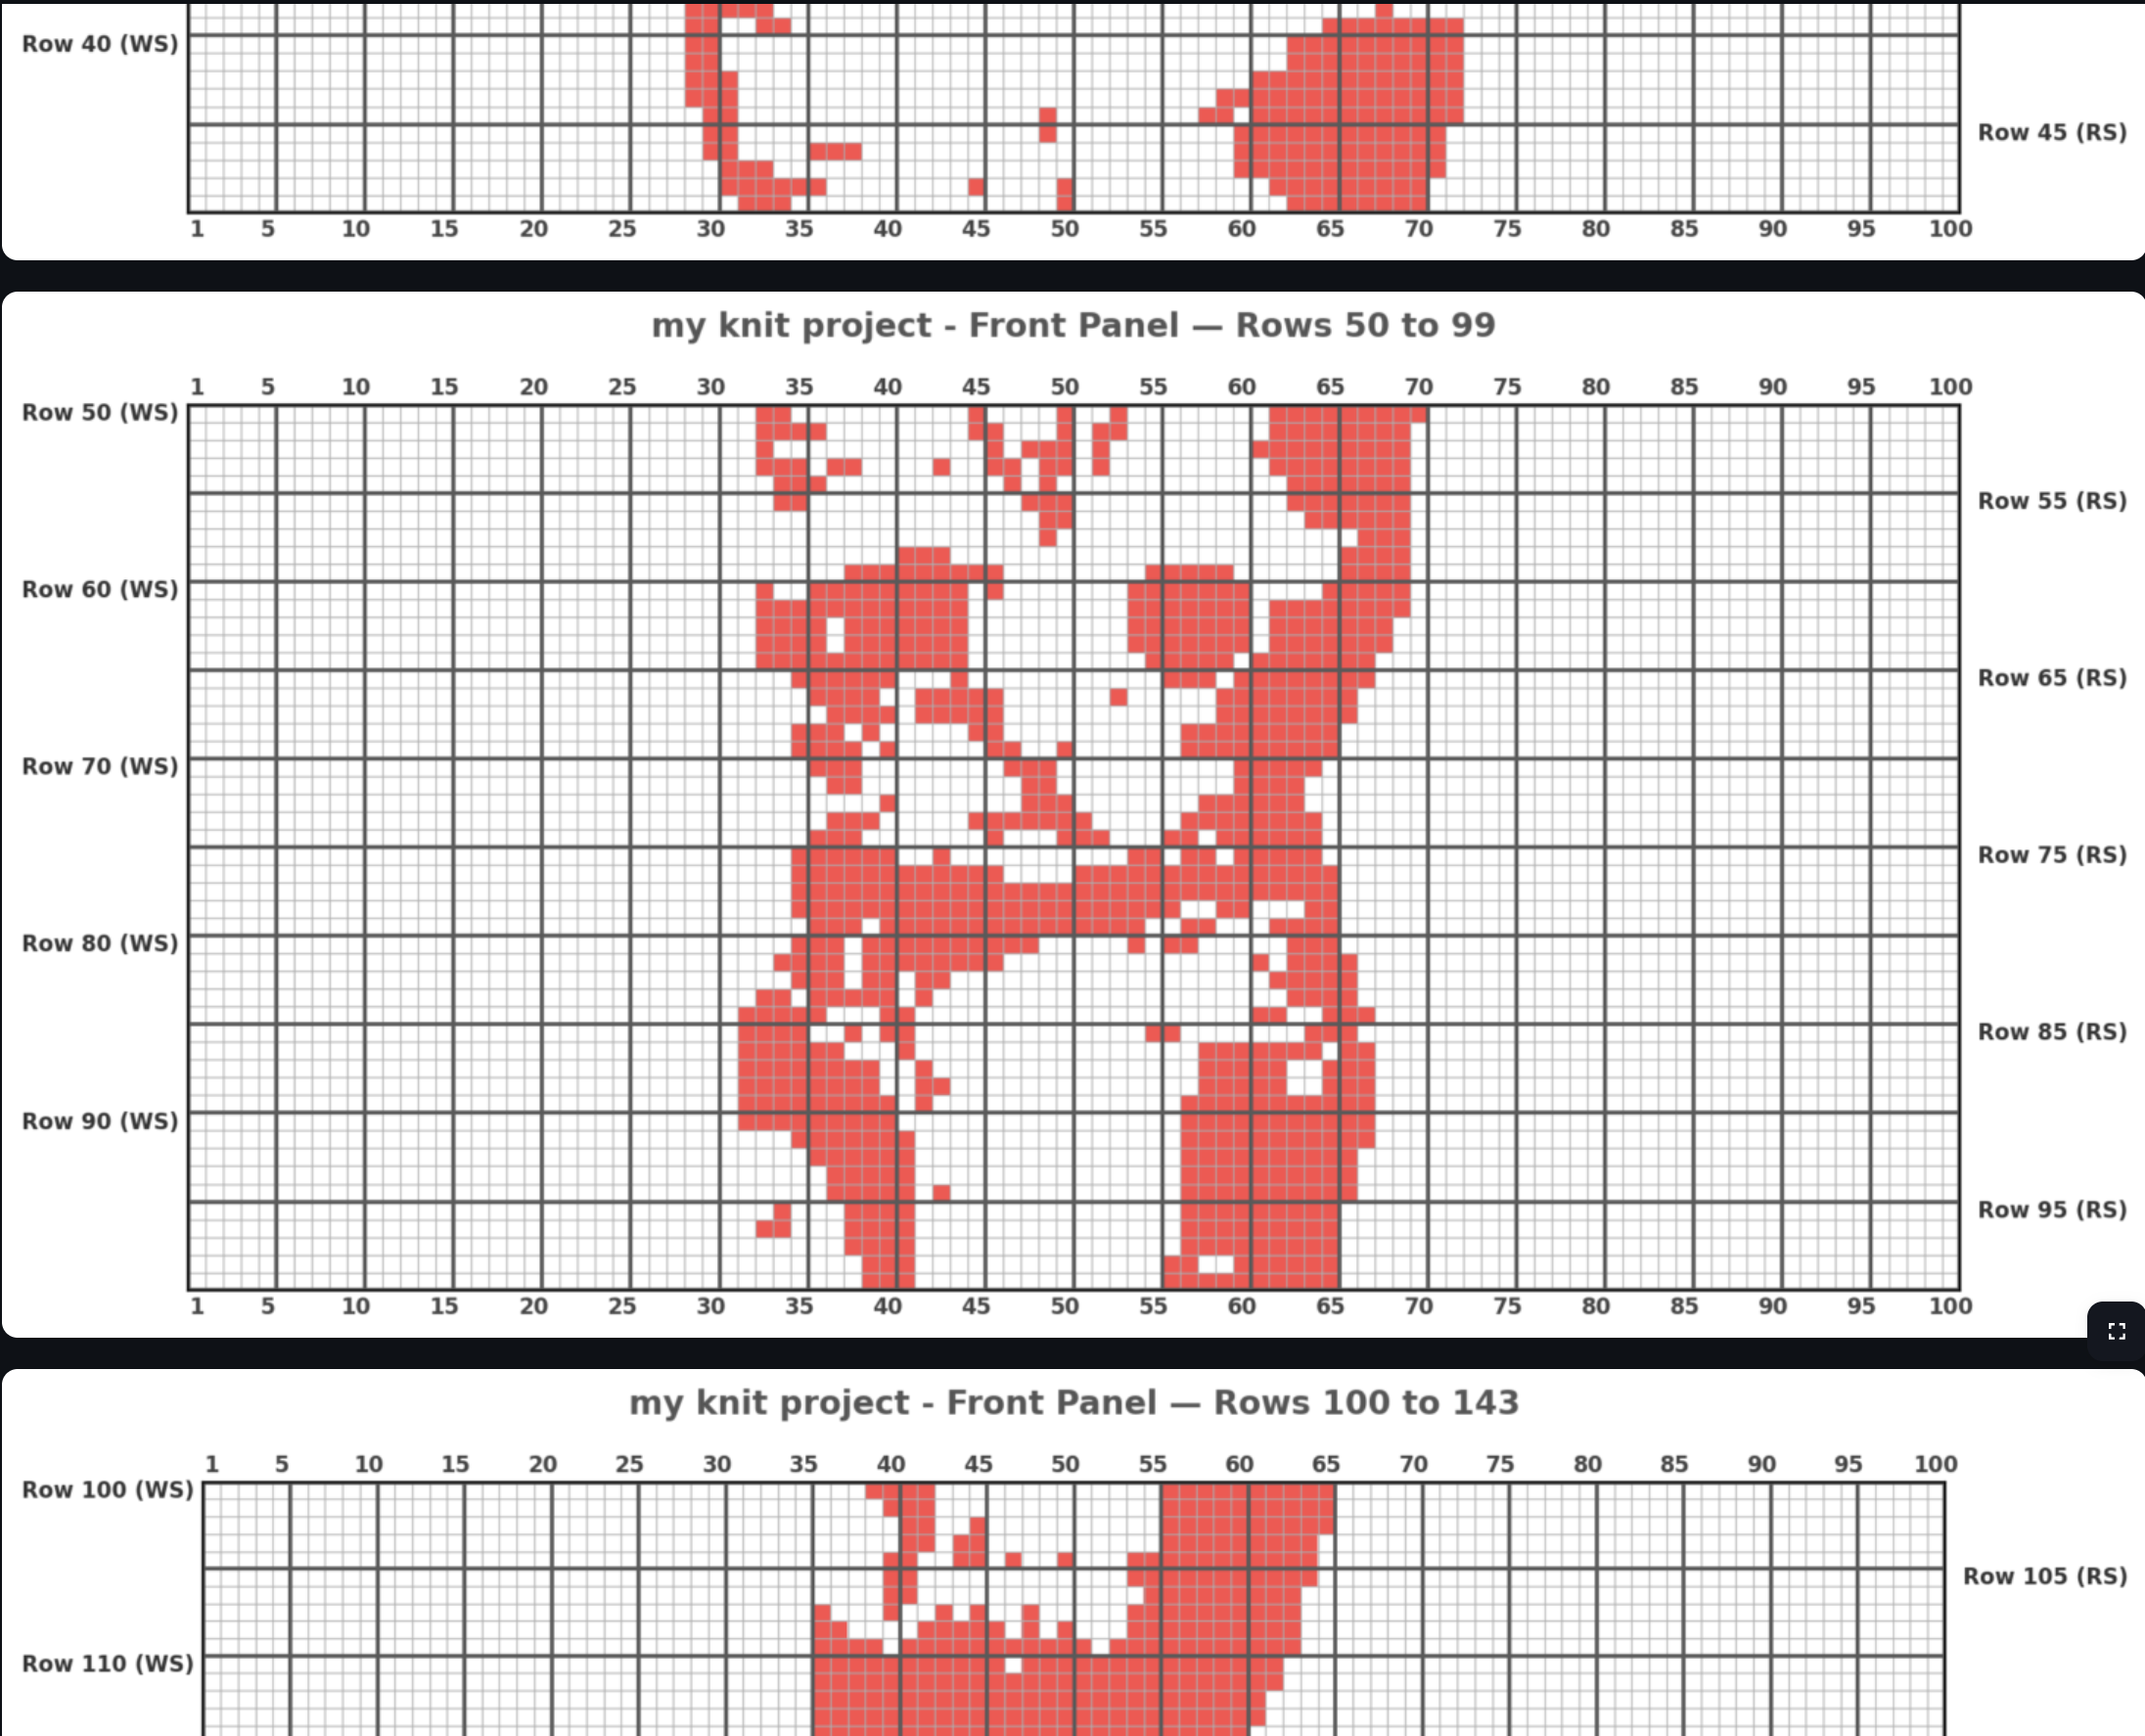

**The Implementation:**
When the user triggers the compiler, the image engine uses Matplotlib to read the final matrix. It slices the massive array into N-row chunks. It filters out the `-1`s (dead space) and applies a Sudoku-style visual overlay, bolding every fifth grid line to help the knitter keep track of their place.
More importantly, it reverse-engineers the short-row data from the math engine to dynamically generate plain-text knitting instructions. It tells the knitter exactly how many stitches to cast on and exactly where to turn their work on the Right Side (RS) and Wrong Side (WS), matching the visual chart.

### Final Thoughts

Because sweater design is an iterative process, the entire state of the app, every matrix, custom edit, layer rotation, and gauge setting—is fully serializable. The user can export their workspace as a JSON payload, close the app, and reload it later with zero data loss.

Knit App successfully bridges the gap between digital arrays and physical textiles, handling the complex geometric math so the user doesn't have to, as well as encouraging creativity with functional design tools. 

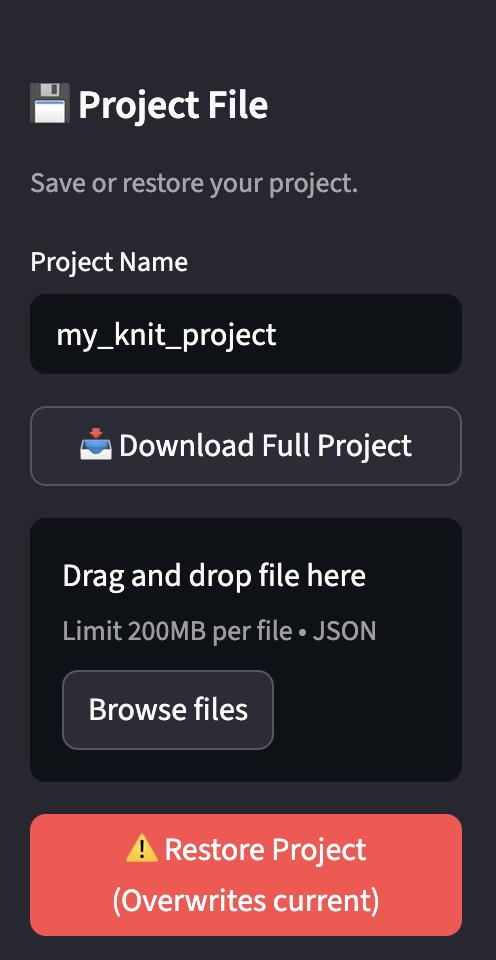

In [ ]:
Layout:
knitting_pattern/
├── src/
│   ├── knitting_pattern/
│   │   ├── __init__.py          # Exposes core calculation functions
│   │   ├── app.py               # Streamlit web application interface
│   │   ├── math_engine.py       # Math logic, matrix grid creation, and chart operations
│   │   └── image_engine.py      # Visualization logic, plotting chart and recognizing alpha patterns
│   └── tests/
│       ├── test_image_engine.py
│       └── test_math_engine.py  